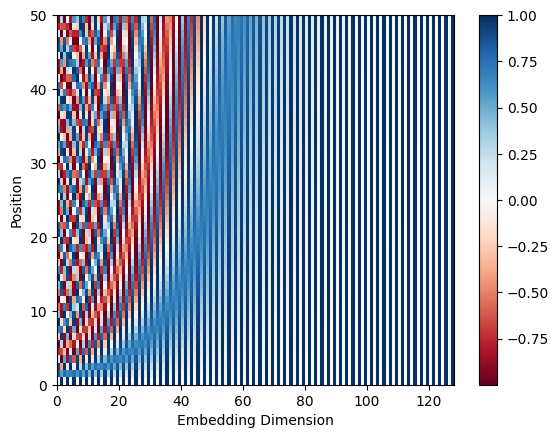

In [1]:
## 위치 인코딩

import math
import torch
from torch import nn
from matplotlib import pyplot as plt


class PositionalEncoding(nn.Module):
  def __init__(self, d_model, max_len, dropout=0.1):
    super().__init__()
    self.dropout = nn.Dropout(p=dropout)

    position = torch.arange(max_len).unsqueeze(1)
    div_term = torch.exp(
        torch.arange(0, d_model, 2) * -(math.log(10000.0) / d_model)
    )

    pe = torch.zeros(max_len, 1, d_model)
    pe[:, 0, 0::2] = torch.sin(position*div_term)
    pe[:, 0, 1::2] = torch.cos(position*div_term)
    self.register_buffer("pe", pe)

  def forward(self, x):
    x = x + self.pe[: x.size(0)]
    return self.dropout(x)


encoding = PositionalEncoding(d_model = 128, max_len = 50)

plt.pcolormesh(encoding.pe.numpy().squeeze(), cmap='RdBu')
plt.xlabel("Embedding Dimension")
plt.xlim((0, 128))
plt.ylabel("Position")
plt.colorbar()
plt.show()

In [2]:
!pip install -q datasets spacy
!python -m spacy download de_core_news_sm
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 115.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('de_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 136.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [3]:
## 데이터세트 다운로드 및 전처리

from torchtext.datasets import Multi30k
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator

def generate_tokens(text_iter, language):
  language_index = {SRC_LANGUAGE: 0, TGT_LANGUAGE: 1}

  for text in text_iter:
    yield token_transform[language](text[language_index[language]])

SRC_LANGUAGE = 'de'
TGT_LANGUAGE = 'en'
UNK_IDX, PAD_IDX, BOS_IDX, EOS_IDX = 0, 1, 2, 3
special_symbols = ["<unk>", "<pad>", "<bos>", "<eos>"]

token_transform = {
    SRC_LANGUAGE: get_tokenizer("spacy", language="de_core_news_sm"),
    TGT_LANGUAGE: get_tokenizer("spacy", language="en_core_web_sm")
}
print("Token Transform:")
print(token_transform)

vocab_transform = {}

for language in [SRC_LANGUAGE, TGT_LANGUAGE]:
  train_iter = Multi30k(split="train", language_pair=(SRC_LANGUAGE, TGT_LANGUAGE))
  vocab_transform[language] = build_vocab_from_iterator(
      generate_tokens(train_iter, language),
      min_freq=1,
      specials=special_symbols,
      special_first=True
  )

for language in [SRC_LANGUAGE, TGT_LANGUAGE]:
  vocab_transform[language].set_default_index(UNK_IDX)

print("Vocab Transform :")
print(vocab_transform)

ModuleNotFoundError: No module named 'torchtext'

호환이 되지 않는 클래스를 사용한 코드여서 아래에 대체 코드를 작성

In [4]:
from collections import Counter

import spacy
from datasets import load_dataset


# ============================================================
# 1. 언어 및 특수 토큰 설정
# ============================================================

SRC_LANGUAGE = "de"
TGT_LANGUAGE = "en"

UNK_IDX = 0
PAD_IDX = 1
BOS_IDX = 2
EOS_IDX = 3

special_symbols = [
    "<unk>",
    "<pad>",
    "<bos>",
    "<eos>"
]


# ============================================================
# 2. Multi30k 데이터셋 다운로드
# ============================================================

dataset = load_dataset("bentrevett/multi30k")

train_data = dataset["train"]
valid_data = dataset["validation"]
test_data = dataset["test"]

print("데이터 개수")
print("Train:", len(train_data))
print("Validation:", len(valid_data))
print("Test:", len(test_data))

print("\n첫 번째 데이터")
print(train_data[0])

README.md:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

train.jsonl:   0%|          | 0.00/4.60M [00:00<?, ?B/s]

val.jsonl:   0%|          | 0.00/164k [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/156k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/29000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1014 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

데이터 개수
Train: 29000
Validation: 1014
Test: 1000

첫 번째 데이터
{'en': 'Two young, White males are outside near many bushes.', 'de': 'Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.'}


In [5]:
# spaCy 모델 로딩
spacy_de = spacy.load("de_core_news_sm")
spacy_en = spacy.load("en_core_web_sm")


def tokenize_de(text):
    """독일어 문장을 토큰 리스트로 변환"""
    return [token.text for token in spacy_de.tokenizer(text)]


def tokenize_en(text):
    """영어 문장을 토큰 리스트로 변환"""
    return [token.text for token in spacy_en.tokenizer(text)]


token_transform = {
    SRC_LANGUAGE: tokenize_de,
    TGT_LANGUAGE: tokenize_en
}

print("Token Transform:")
print(token_transform)

print("\n독일어 토큰화 예시:")
print(token_transform[SRC_LANGUAGE](train_data[0][SRC_LANGUAGE]))

print("\n영어 토큰화 예시:")
print(token_transform[TGT_LANGUAGE](train_data[0][TGT_LANGUAGE]))

Token Transform:
{'de': <function tokenize_de at 0x7f7b18c098a0>, 'en': <function tokenize_en at 0x7f7af8c98ae0>}

독일어 토큰화 예시:
['Zwei', 'junge', 'weiße', 'Männer', 'sind', 'im', 'Freien', 'in', 'der', 'Nähe', 'vieler', 'Büsche', '.']

영어 토큰화 예시:
['Two', 'young', ',', 'White', 'males', 'are', 'outside', 'near', 'many', 'bushes', '.']


In [6]:
class SimpleVocab:
    """
    torchtext.vocab.Vocab에서 자주 사용하는 기능을 대신하는 클래스
    """

    def __init__(self, token_iterator, min_freq=1, specials=None):
        if specials is None:
            specials = []

        counter = Counter()

        # 전체 학습 데이터의 토큰 빈도 계산
        for tokens in token_iterator:
            counter.update(tokens)

        # 빈도 내림차순, 같은 빈도라면 알파벳순
        normal_tokens = sorted(
            [
                token
                for token, frequency in counter.items()
                if frequency >= min_freq and token not in specials
            ],
            key=lambda token: (-counter[token], token)
        )

        # 특수 토큰을 vocabulary 앞부분에 배치
        self.itos = list(specials) + normal_tokens
        self.stoi = {
            token: index
            for index, token in enumerate(self.itos)
        }

        self.default_index = None

    def set_default_index(self, index):
        """등록되지 않은 단어가 들어왔을 때 사용할 인덱스 설정"""
        self.default_index = index

    def __getitem__(self, token):
        """하나의 토큰을 인덱스로 변환"""
        if token in self.stoi:
            return self.stoi[token]

        if self.default_index is not None:
            return self.default_index

        raise KeyError(f"Vocabulary에 없는 토큰입니다: {token}")

    def __call__(self, tokens):
        """여러 토큰을 인덱스 리스트로 변환"""
        return [self[token] for token in tokens]

    def __len__(self):
        """Vocabulary 크기 반환"""
        return len(self.itos)

    def lookup_token(self, index):
        """인덱스 하나를 토큰으로 변환"""
        return self.itos[index]

    def lookup_tokens(self, indices):
        """여러 인덱스를 토큰 리스트로 변환"""
        return [self.itos[index] for index in indices]

    def lookup_indices(self, tokens):
        """여러 토큰을 인덱스 리스트로 변환"""
        return [self[token] for token in tokens]

    def get_itos(self):
        """index-to-string 리스트 반환"""
        return self.itos

    def get_stoi(self):
        """string-to-index 딕셔너리 반환"""
        return self.stoi

In [7]:
def generate_tokens(data_iter, language):
    """
    데이터셋에서 지정된 언어의 문장을 가져와
    토큰 리스트를 하나씩 생성
    """
    for data in data_iter:
        text = data[language]
        yield token_transform[language](text)


vocab_transform = {}

for language in [SRC_LANGUAGE, TGT_LANGUAGE]:
    vocab_transform[language] = SimpleVocab(
        token_iterator=generate_tokens(train_data, language),
        min_freq=1,
        specials=special_symbols
    )

    # vocabulary에 없는 단어는 <unk>의 인덱스 0으로 처리
    vocab_transform[language].set_default_index(UNK_IDX)


print("Vocab Transform:")
print(vocab_transform)

print("\n독일어 vocabulary 크기:")
print(len(vocab_transform[SRC_LANGUAGE]))

print("\n영어 vocabulary 크기:")
print(len(vocab_transform[TGT_LANGUAGE]))

Vocab Transform:
{'de': <__main__.SimpleVocab object at 0x7f7b18c8e270>, 'en': <__main__.SimpleVocab object at 0x7f7b18d27110>}

독일어 vocabulary 크기:
19214

영어 vocabulary 크기:
10837


In [8]:
sample_de = train_data[0][SRC_LANGUAGE]
sample_en = train_data[0][TGT_LANGUAGE]

de_tokens = token_transform[SRC_LANGUAGE](sample_de)
en_tokens = token_transform[TGT_LANGUAGE](sample_en)

de_indices = vocab_transform[SRC_LANGUAGE](de_tokens)
en_indices = vocab_transform[TGT_LANGUAGE](en_tokens)

print("독일어 문장:")
print(sample_de)

print("\n독일어 토큰:")
print(de_tokens)

print("\n독일어 인덱스:")
print(de_indices)

print("\n영어 문장:")
print(sample_en)

print("\n영어 토큰:")
print(en_tokens)

print("\n영어 인덱스:")
print(en_indices)

독일어 문장:
Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.

독일어 토큰:
['Zwei', 'junge', 'weiße', 'Männer', 'sind', 'im', 'Freien', 'in', 'der', 'Nähe', 'vieler', 'Büsche', '.']

독일어 인덱스:
[21, 85, 257, 31, 87, 22, 94, 7, 16, 112, 7910, 3209, 4]

영어 문장:
Two young, White males are outside near many bushes.

영어 토큰:
['Two', 'young', ',', 'White', 'males', 'are', 'outside', 'near', 'many', 'bushes', '.']

영어 인덱스:
[19, 25, 15, 1169, 808, 17, 57, 84, 336, 1339, 5]


In [9]:
### 트랜스포머 모델 구성

import math
import torch
from torch import nn


class PositionalEncoding(nn.Module):
  def __init__(self, d_model, max_len, dropout=0.1):
    super().__init__()
    self.dropout = nn.Dropout(p=dropout)

    position = torch.arange(max_len).unsqueeze(1)
    div_term = torch.exp(
        torch.arange(0, d_model, 2) * -(math.log(10000.0) / d_model)
    )

    pe = torch.zeros(max_len, 1, d_model)
    pe[:, 0, 0::2] = torch.sin(position*div_term)
    pe[:, 0, 1::2] = torch.cos(position*div_term)
    self.register_buffer("pe", pe)

  def forward(self, x):
    x = x + self.pe[: x.size(0)]
    return self.dropout(x)


class TokenEmbedding(nn.Module):
  def __init__(self, vocab_size, emb_size):
    super().__init__()
    self.embedding = nn.Embedding(vocab_size, emb_size)
    self.emb_size = emb_size

  def forward(self, tokens):
    return self.embedding(tokens.long()) * math.sqrt(self.emb_size)

class Seq2SeqTransformer(nn.Module):
  def __init__(
      self,
      num_encoder_layers,
      num_decoder_layers,
      emb_size,
      max_len,
      nhead,
      src_vocab_size,
      tgt_vocab_size,
      dim_feedforward=512,
      dropout=0.1
  ):
    super().__init__()
    self.src_tok_emb = TokenEmbedding(src_vocab_size, emb_size)
    self.tgt_tok_emb = TokenEmbedding(tgt_vocab_size, emb_size)
    self.positional_encoding = PositionalEncoding(d_model = emb_size, max_len = max_len, dropout = dropout)
    self.transformer = nn.Transformer(
        d_model = emb_size,
        nhead = nhead,
        num_encoder_layers = num_encoder_layers,
        num_decoder_layers = num_decoder_layers,
        dim_feedforward = dim_feedforward,
        dropout = dropout
    )
    self.generator = nn.Linear(emb_size, tgt_vocab_size)

  def forward(self, src, tgt, src_mask, tgt_mask, src_padding_mask,
              tgt_padding_mask, memory_key_padding_mask):
    src_emb = self.positional_encoding(
        self.src_tok_emb(src)
    )

    tgt_emb = self.positional_encoding(
        self.tgt_tok_emb(tgt)
    )

    # Encoder와 Decoder를 통과한 Transformer 출력
    outs = self.transformer(
        src=src_emb,
        tgt=tgt_emb,
        src_mask=src_mask,
        tgt_mask=tgt_mask,
        memory_mask=None,
        src_key_padding_mask=src_padding_mask,
        tgt_key_padding_mask=tgt_padding_mask,
        memory_key_padding_mask=memory_key_padding_mask
    )

    # 각 위치의 출력을 vocabulary 크기의 logits으로 변환
    return self.generator(outs)

  def encode(self, src, src_mask):
    return self.transformer.encoder(self.positional_encoding(self.src_tok_emb(src)), src_mask)

  def decode(self, tgt, memory, tgt_mask):
    return self.transformer.decoder(self.positional_encoding(self.tgt_tok_emb(tgt)), memory, tgt_mask)



In [10]:
### 트랜스포머 클래스
transformer = torch.nn.Transformer(
    d_model = 512,
    nhead=8,
    num_encoder_layers=6,
    num_decoder_layers=6,
    dim_feedforward=2048,
    dropout=0.1,
    activation='relu',
    layer_norm_eps = 1e-05,
)

/usr/local/lib/python3.13/dist-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = TransformerEncoder(


In [ ]:
### 트랜스포머 순방향 메서드
output = transformer.forward(
    src, tgt, src_mask=None, tgt_mask=None,
    memory_mask = None, src_key_padding_mask=None,
    tgt_key_padding_mask=None, memory_key_padding_mask=None
)

위 코드는 작동하지 않는 코드임. 따라서 따로 실행하지 않음

In [11]:
### 트랜스포머 모델 구조

from torch import optim

BATCH_SIZE = 128
DEVICE = 'cuda' if torch.cuda.is_available() else "cpu"

model = Seq2SeqTransformer(
    num_encoder_layers=3,
    num_decoder_layers=3,
    emb_size = 512,
    max_len=512,
    nhead = 8,
    src_vocab_size = len(vocab_transform[SRC_LANGUAGE]),
    tgt_vocab_size = len(vocab_transform[TGT_LANGUAGE]),
    dim_feedforward=512,
).to(DEVICE)

criterion = torch.nn.CrossEntropyLoss(ignore_index=PAD_IDX).to(DEVICE)
optimizer = optim.Adam(model.parameters())

for main_name, main_module in model.named_children():
  print(main_name)
  for sub_name, sub_module in main_module.named_children():
    print("L",sub_name)
    for ssub_name, ssub_module in sub_module.named_children():
      print("| L", ssub_name)
      for sssub_name, sssub_module in ssub_module.named_children():
        print("| | L", sssub_name)

src_tok_emb
L embedding
tgt_tok_emb
L embedding
positional_encoding
L dropout
transformer
L encoder
| L layers
| | L 0
| | L 1
| | L 2
| L norm
L decoder
| L layers
| | L 0
| | L 1
| | L 2
| L norm
generator


In [12]:
# ============================================================
# 배치 데이터 생성
# ============================================================

import torch

from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence


BATCH_SIZE = 128


# 여러 전처리 함수를 순서대로 적용
def sequential_transforms(*transforms):

    def func(txt_input):

        for transform in transforms:
            txt_input = transform(txt_input)

        return txt_input

    return func


# 토큰 인덱스 앞뒤에 <bos>, <eos> 추가
def input_transform(token_ids):

    return torch.tensor(
        [BOS_IDX] + token_ids + [EOS_IDX],
        dtype=torch.long
    )


# 언어별 전체 전처리 과정
# 문장 → 토큰 → 인덱스 → BOS/EOS 추가
text_transform = {}

for language in [SRC_LANGUAGE, TGT_LANGUAGE]:

    text_transform[language] = sequential_transforms(
        token_transform[language],
        vocab_transform[language],
        input_transform
    )


# 하나의 batch를 패딩된 Tensor로 변환
def collator(batch):

    src_batch = []
    tgt_batch = []

    for sample in batch:

        # Hugging Face 데이터셋의 각 sample은 딕셔너리 형태
        src_sample = sample[SRC_LANGUAGE]
        tgt_sample = sample[TGT_LANGUAGE]

        # 전처리 후 Tensor를 리스트에 추가
        src_batch.append(
            text_transform[SRC_LANGUAGE](src_sample.rstrip("\n"))
        )

        tgt_batch.append(
            text_transform[TGT_LANGUAGE](tgt_sample.rstrip("\n"))
        )

    # 각 문장의 길이를 batch 내 최장 문장 길이에 맞춤
    src_batch = pad_sequence(
        src_batch,
        padding_value=PAD_IDX
    )

    tgt_batch = pad_sequence(
        tgt_batch,
        padding_value=PAD_IDX
    )

    return src_batch, tgt_batch


# 기존의 Multi30k(split="valid")를 대체
data_iter = dataset["validation"]

dataloader = DataLoader(
    data_iter,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collator
)


# 첫 번째 batch 가져오기
source_tensor, target_tensor = next(iter(dataloader))


# 원본 데이터 한 개 확인
sample = next(iter(data_iter))

print("(source, target):")
print(
    (
        sample[SRC_LANGUAGE],
        sample[TGT_LANGUAGE]
    )
)

print("\nsource_batch shape:", source_tensor.shape)
print(source_tensor)

print("\ntarget_batch shape:", target_tensor.shape)
print(target_tensor)

(source, target):
('Eine Gruppe von Männern lädt Baumwolle auf einen Lastwagen', 'A group of men are loading cotton onto a truck')

source_batch shape: torch.Size([35, 128])
tensor([[   2,    2,    2,  ...,    2,    2,    2],
        [  14,    5,    5,  ...,    5,   21,    5],
        [  38,   12,   35,  ...,   12, 1750,   69],
        ...,
        [   1,    1,    1,  ...,    1,    1,    1],
        [   1,    1,    1,  ...,    1,    1,    1],
        [   1,    1,    1,  ...,    1,    1,    1]])

target_batch shape: torch.Size([30, 128])
tensor([[   2,    2,    2,  ...,    2,    2,    2],
        [   6,    6,    6,  ...,  250,   19,    6],
        [  39,   12,   35,  ...,   12, 3254,   61],
        ...,
        [   1,    1,    1,  ...,    1,    1,    1],
        [   1,    1,    1,  ...,    1,    1,    1],
        [   1,    1,    1,  ...,    1,    1,    1]])


In [13]:
### 어텐션 마스크 생성

def generate_square_subsequent_mask(s):
  mask = (torch.triu(torch.ones((s,s), device=DEVICE))==1).transpose(0,1)
  mask = (
      mask.float()
      .masked_fill(mask == 0, float("-inf"))
      .masked_fill(mask == 1, float(0.0))
  )
  return mask

def create_mask(src, tgt):
  src_seq_len = src.shape[0]
  tgt_seq_len = tgt.shape[0]

  tgt_mask = generate_square_subsequent_mask(tgt_seq_len)
  src_mask = torch.zeros((src_seq_len, src_seq_len), device=DEVICE).type(torch.bool)

  src_padding_mask = (src == PAD_IDX).transpose(0,1)
  tgt_padding_mask = (tgt == PAD_IDX).transpose(0,1)
  return src_mask, tgt_mask, src_padding_mask, tgt_padding_mask

target_input = target_tensor[:-1, :]
target_out = target_tensor[1:, :]

source_mask, target_mask, source_padding_mask, target_padding_mask = create_mask(
    source_tensor, target_input)

print("source_mask : ", source_mask.shape)
print(source_mask)
print("target_mask : ", target_mask.shape)
print(target_mask)
print("source_padding_mask : ", source_padding_mask.shape)
print(source_padding_mask)
print("target_padding_mask : ", target_padding_mask.shape)
print(target_padding_mask)

source_mask :  torch.Size([35, 35])
tensor([[False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        ...,
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False]], device='cuda:0')
target_mask :  torch.Size([29, 29])
tensor([[0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
         -inf, -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
         -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
         -inf, -inf, -

In [14]:
# ============================================================
# 모델 학습 및 평가
# ============================================================

import torch

from torch.utils.data import DataLoader


def run(model, optimizer, criterion, split):

    is_train = split == "train"

    # 학습 또는 평가 모드 설정
    if is_train:
        model.train()
    else:
        model.eval()

    # torchtext와 Hugging Face의 split 이름이 다름
    split_name = {
        "train": "train",
        "valid": "validation",
        "validation": "validation",
        "test": "test"
    }[split]

    # 앞에서 다운로드한 Hugging Face dataset 사용
    data_iter = dataset[split_name]

    dataloader = DataLoader(
        data_iter,
        batch_size=BATCH_SIZE,
        shuffle=is_train,
        collate_fn=collator
    )

    total_loss = 0.0

    # train일 때만 gradient 계산
    with torch.set_grad_enabled(is_train):

        for source_batch, target_batch in dataloader:

            source_batch = source_batch.to(DEVICE)
            target_batch = target_batch.to(DEVICE)

            # 디코더 입력과 정답을 한 칸씩 이동
            target_input = target_batch[:-1, :]
            target_out = target_batch[1:, :]

            (
                src_mask,
                tgt_mask,
                src_padding_mask,
                tgt_padding_mask
            ) = create_mask(
                source_batch,
                target_input
            )

            if is_train:
                optimizer.zero_grad()

            logits = model(
                src=source_batch,
                tgt=target_input,
                src_mask=src_mask,
                tgt_mask=tgt_mask,
                src_padding_mask=src_padding_mask,
                tgt_padding_mask=tgt_padding_mask,
                memory_key_padding_mask=src_padding_mask

            )

            loss = criterion(
                logits.reshape(-1, logits.shape[-1]),
                target_out.reshape(-1)
            )

            if is_train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item()

    return total_loss / len(dataloader)


# ============================================================
# 학습 실행
# ============================================================

NUM_EPOCHS = 5

for epoch in range(1, NUM_EPOCHS + 1):

    train_loss = run(
        model,
        optimizer,
        criterion,
        split="train"
    )

    valid_loss = run(
        model,
        optimizer,
        criterion,
        split="valid"
    )

    print(
        f"Epoch: {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Valid Loss: {valid_loss:.4f}"
    )

/usr/local/lib/python3.13/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


Epoch: 01 | Train Loss: 4.5171 | Valid Loss: 3.7304
Epoch: 02 | Train Loss: 3.6067 | Valid Loss: 3.4610
Epoch: 03 | Train Loss: 3.3569 | Valid Loss: 3.4327
Epoch: 04 | Train Loss: 3.2433 | Valid Loss: 3.3607
Epoch: 05 | Train Loss: 3.1600 | Valid Loss: 3.3402


In [18]:
### 트랜스포머 모델 번역 결과

def greedy_decode(model, source_tensor, source_mask, max_len, start_symbol):
  source_tensor = source_tensor.to(DEVICE)
  source_mask = source_mask.to(DEVICE)

  memory = model.encode(source_tensor, source_mask)

  ys = torch.ones(1,1).fill_(start_symbol).type(torch.long).to(DEVICE)
  for i in range(max_len -1):
    memory = memory.to(DEVICE)
    target_mask = generate_square_subsequent_mask(ys.size(0))
    target_mask = target_mask.type(torch.bool).to(DEVICE)

    out = model.decode(ys, memory, target_mask)
    out = out.transpose(0,1)
    prob = model.generator(out[:, -1])
    _, next_word = torch.max(prob, dim=1)
    next_word = next_word.item()

    ys = torch.cat(
        [ys, torch.ones(1,1).type_as(source_tensor.data).fill_(next_word)], dim=0
    )
    if next_word == EOS_IDX:
      break

  return ys

def translate(model, source_sentence):
  model.eval()
  source_tensor = text_transform[SRC_LANGUAGE](source_sentence).view(-1,1)
  num_tokens = source_tensor.shape[0]
  src_mask = (torch.zeros(num_tokens, num_tokens)).type(torch.bool)
  tgt_tokens = greedy_decode(
      model, source_tensor, src_mask, max_len=num_tokens + 5, start_symbol=BOS_IDX
  ).flatten()
  output = vocab_transform[TGT_LANGUAGE].lookup_tokens(list(map(int, tgt_tokens)))[1:-1]

  return " ".join(output)


output_oov = translate(model, "Eine Gruppe von Menschen steht vor einem Iglu.")
output = translate(model, "Eine Gruppen von Menschen steht vor einem Gebäude")

print(output_oov)
print(output)

A group of people are standing outside of a building .
A group of people are sitting on a bench .
